<a href="https://colab.research.google.com/github/msminhchile0808-del/Quantitative-Analysis-of-Apple-Stock-2020-2025/blob/main/Stock-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Loads packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from google.colab import drive
drive.mount('/content/drive')

# Load and clean data

df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/apple_stock.csv')
display(df)

df.columns = [c.strip() for c in df.columns]
display(df.columns)

df.info()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,Adj Close,Close,High,Low,Open,Volume
0,1980-12-12,0.098834,0.128348,0.128906,0.128348,0.128348,469033600
1,1980-12-15,0.093678,0.121652,0.122210,0.121652,0.122210,175884800
2,1980-12-16,0.086802,0.112723,0.113281,0.112723,0.113281,105728000
3,1980-12-17,0.088951,0.115513,0.116071,0.115513,0.115513,86441600
4,1980-12-18,0.091530,0.118862,0.119420,0.118862,0.118862,73449600
...,...,...,...,...,...,...,...
11102,2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300
11103,2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500
11104,2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700
11105,2025-01-02,243.850006,243.850006,249.100006,241.820007,248.929993,55558000


Index(['Unnamed: 0', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11107 entries, 0 to 11106
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  11107 non-null  object 
 1   Adj Close   11107 non-null  float64
 2   Close       11107 non-null  float64
 3   High        11107 non-null  float64
 4   Low         11107 non-null  float64
 5   Open        11107 non-null  float64
 6   Volume      11107 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 607.5+ KB


In [ ]:
# filter to 2020-2025 (inclusive)

# Rename the date column and convert it to datetime objects
df.rename(columns={"Unnamed: 0": "date"}, inplace=True)
df["date"] = pd.to_datetime(df["date"])

START = pd.Timestamp("2020-01-01")
END   = pd.Timestamp("2025-12-31")
data = df.loc[(df["date"] >= START) & (df["date"] <= END)].reset_index(drop=True)

print("Filtered date range:", data["date"].min().date(), "→", data["date"].max().date())
print("Rows after filter:", len(data))
display(data.head())

Filtered date range: 2020-01-02 → 2025-01-03
Rows after filter: 1260


,date,Adj Close,Close,High,Low,Open,Volume
0,2020-01-02,72.796043,75.087502,75.150002,73.797501,74.059998,135480400
1,2020-01-03,72.088303,74.357498,75.144997,74.125000,74.287498,146322800
2,2020-01-06,72.662712,74.949997,74.989998,73.187500,73.447502,118387200
3,2020-01-07,72.320969,74.597504,75.224998,74.370003,74.959999,108872000
4,2020-01-08,73.484375,75.797501,76.110001,74.290001,74.290001,132079200


In [ ]:
# Volume weighted average price. Used to calculate the ratio of pricing to volume and give better predictions
data['VWAP'] = (data['Close'] * data['Volume']).cumsum() / data['Volume'].cumsum()
data.head()

,date,Adj Close,Close,High,Low,Open,Volume,VWAP
0,2020-01-02,72.796043,75.087502,75.150002,73.797501,74.059998,135480400,75.087502
1,2020-01-03,72.088303,74.357498,75.144997,74.125000,74.287498,146322800,74.708456
2,2020-01-06,72.662712,74.949997,74.989998,73.187500,73.447502,118387200,74.779911
3,2020-01-07,72.320969,74.597504,75.224998,74.370003,74.959999,108872000,74.740900
4,2020-01-08,73.484375,75.797501,76.110001,74.290001,74.290001,132079200,74.958566


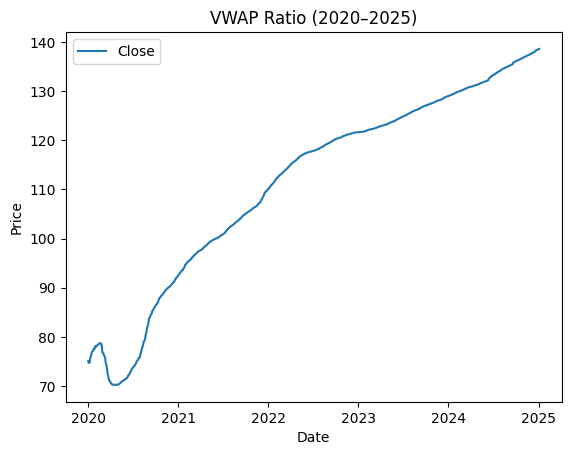

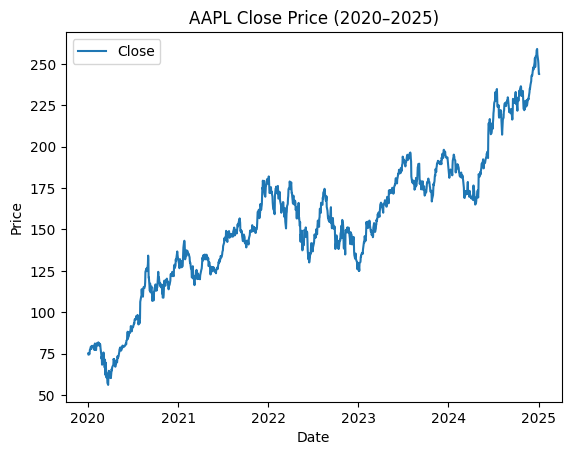

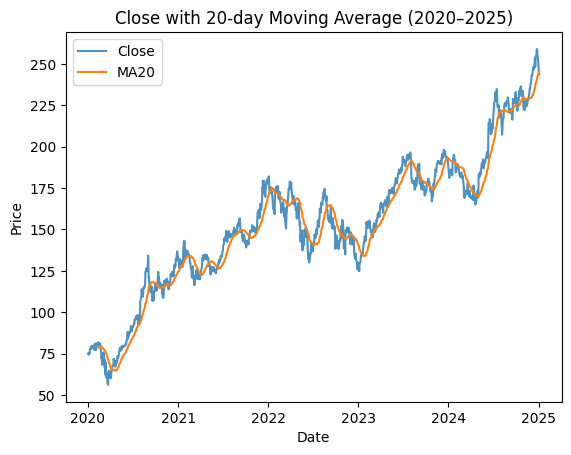

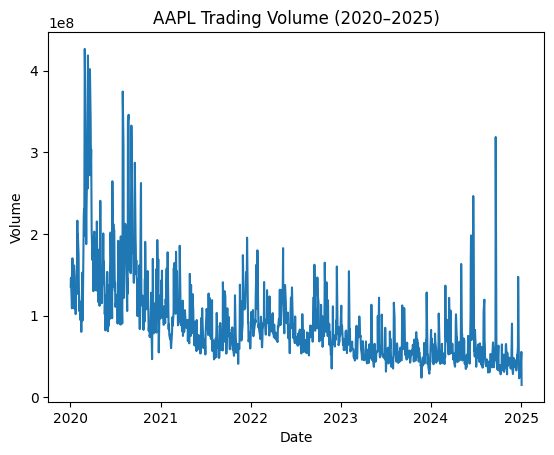

In [ ]:
# ** VWAP Chart **
plt.figure()
plt.plot(data["date"], data["VWAP"], label="Close")
plt.title("VWAP Ratio (2020–2025)")
plt.xlabel("Date"); plt.ylabel("Price"); plt.legend(); plt.show()

# ** Price patterns **
# Close over time - shows the basic price trend.
plt.figure()
plt.plot(data["date"], data["Close"], label="Close")
plt.title("AAPL Close Price (2020–2025)")
plt.xlabel("Date"); plt.ylabel("Price"); plt.legend(); plt.show()


# 20-day moving average - get a closer look day-to-day so trend is easier to see.
data["ma20"] = data["Close"].rolling(30).mean()
data["ma20"] = data["Close"].rolling(30).mean()
plt.figure()
plt.plot(data["date"], data["Close"], label="Close", alpha=0.8)
plt.plot(data["date"], data["ma20"],  label="MA20")
plt.title("Close with 20-day Moving Average (2020–2025)")
plt.xlabel("Date"); plt.ylabel("Price"); plt.legend(); plt.show()


# Volume over time- shows trading activity patterns (spikes/quiet periods).
plt.figure()
plt.plot(data["date"], data["Volume"], label="Volume")
plt.title("AAPL Trading Volume (2020–2025)")
plt.xlabel("Date"); plt.ylabel("Volume"); plt.show()




Golden Crosses on: Index([  459,   856,  1045,  1263,  1907,  2135,  2384,  2545,  2793,  3034,
        3341,  3472,  3654,  4033,  4226,  4354,  4652,  5189,  5318,  5660,
        6507,  6920,  7169,  8258,  9007,  9680, 10535, 10657, 10966],
      dtype='int64')
Death Crosses on: Index([  683,   961,  1084,  1766,  1969,  2288,  2472,  2668,  2915,  3138,
        3410,  3635,  3747,  4065,  4299,  4628,  4944,  5239,  5445,  6441,
        6870,  7009,  8070,  8754,  9589, 10457, 10544, 10903],
      dtype='int64')
Breakouts on: Index([ 4209,  9917,  9956,  9993, 10008, 10043, 10322, 10335, 10411, 10495,
       10498, 10559, 10616, 10620, 10624, 10625, 10656, 10664, 10688, 10726,
       10819, 10841, 10938, 10946, 10958, 10960, 10964, 10965, 10979, 10980,
       10981, 10982, 10983, 10986, 11051, 11081, 11083, 11084, 11085, 11086,
       11089, 11090, 11094, 11095, 11098, 11099, 11100, 11101],
      dtype='int64')


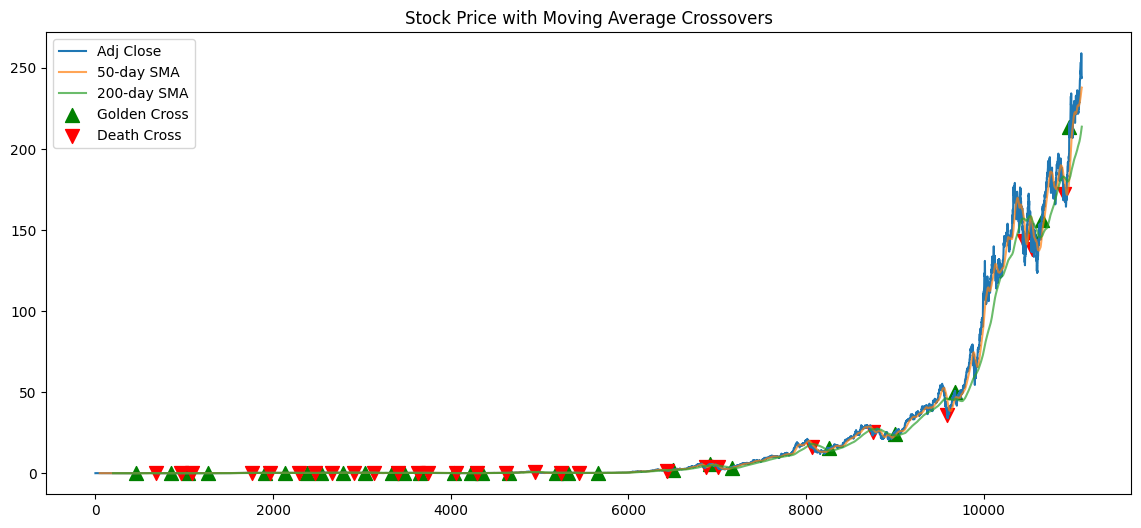

In [ ]:
# Detect Moving Average Crossover Pattern
# Short-term and long-term moving averages
df['SMA_50'] = df['Adj Close'].rolling(window=50).mean()
df['SMA_200'] = df['Adj Close'].rolling(window=200).mean()

# Detect crossovers
df['Golden_Cross'] = (df['SMA_50'] > df['SMA_200']) & (df['SMA_50'].shift(1) <= df['SMA_200'].shift(1))
df['Death_Cross'] = (df['SMA_50'] < df['SMA_200']) & (df['SMA_50'].shift(1) >= df['SMA_200'].shift(1))

# Get dates of these events
golden_cross_dates = df[df['Golden_Cross']].index
death_cross_dates = df[df['Death_Cross']].index

print("Golden Crosses on:", golden_cross_dates)
print("Death Crosses on:", death_cross_dates)

# Detect Price Breakouts
lookback_days = 20
df['Recent_High'] = df['High'].rolling(window=lookback_days).max()
df['Breakout'] = df['Adj Close'] > df['Recent_High'].shift(1)

breakout_dates = df[df['Breakout']].index
print("Breakouts on:", breakout_dates)

# Visualize Patterns
# import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df.index, df['Adj Close'], label='Adj Close')
plt.plot(df.index, df['SMA_50'], label='50-day SMA', alpha=0.7)
plt.plot(df.index, df['SMA_200'], label='200-day SMA', alpha=0.7)

# Mark Golden Crosses
plt.scatter(golden_cross_dates, df.loc[golden_cross_dates, 'Adj Close'], color='green', label='Golden Cross', marker='^', s=100)
plt.scatter(death_cross_dates, df.loc[death_cross_dates, 'Adj Close'], color='red', label='Death Cross', marker='v', s=100)

plt.legend()
plt.title("Stock Price with Moving Average Crossovers")
plt.show()

In [ ]:
# Golden Cross DataFrame
golden_cross_df = df[df['Golden_Cross']].copy()

# Death Cross DataFrame
death_cross_df = df[df['Death_Cross']].copy()

# Optional: reset index so Date becomes a column again
golden_cross_df.reset_index(inplace=True)
death_cross_df.reset_index(inplace=True)

print("Golden Cross DataFrame:")
print(golden_cross_df[['date', 'Adj Close', 'SMA_50', 'SMA_200']])

print("\nDeath Cross DataFrame:")
print(death_cross_df[['date', 'Adj Close', 'SMA_50', 'SMA_200']])


Golden Cross DataFrame:
         date   Adj Close      SMA_50     SMA_200
0  1982-10-07    0.075200    0.056783    0.056157
1  1984-05-02    0.113445    0.091736    0.091669
2  1985-01-30    0.102702    0.094168    0.093962
3  1985-12-11    0.067895    0.063426    0.063347
4  1988-06-29    0.321712    0.291923    0.291388
5  1989-05-24    0.334399    0.275100    0.275017
6  1990-05-18    0.280623    0.286818    0.286480
7  1991-01-08    0.308132    0.272166    0.271650
8  1991-12-31    0.405398    0.370343    0.369812
9  1992-12-11    0.417096    0.381716    0.380683
10 1994-03-01    0.267148    0.242599    0.241305
11 1994-09-07    0.268204    0.235715    0.234783
12 1995-05-26    0.319637    0.289780    0.289651
13 1996-11-22    0.190174    0.182474    0.181958
14 1997-08-29    0.163813    0.140955    0.140344
15 1998-03-05    0.181231    0.141355    0.140550
16 1999-05-11    0.337043    0.281840    0.281512
17 2001-06-26    0.357754    0.344360    0.342174
18 2002-01-04    0.356851 

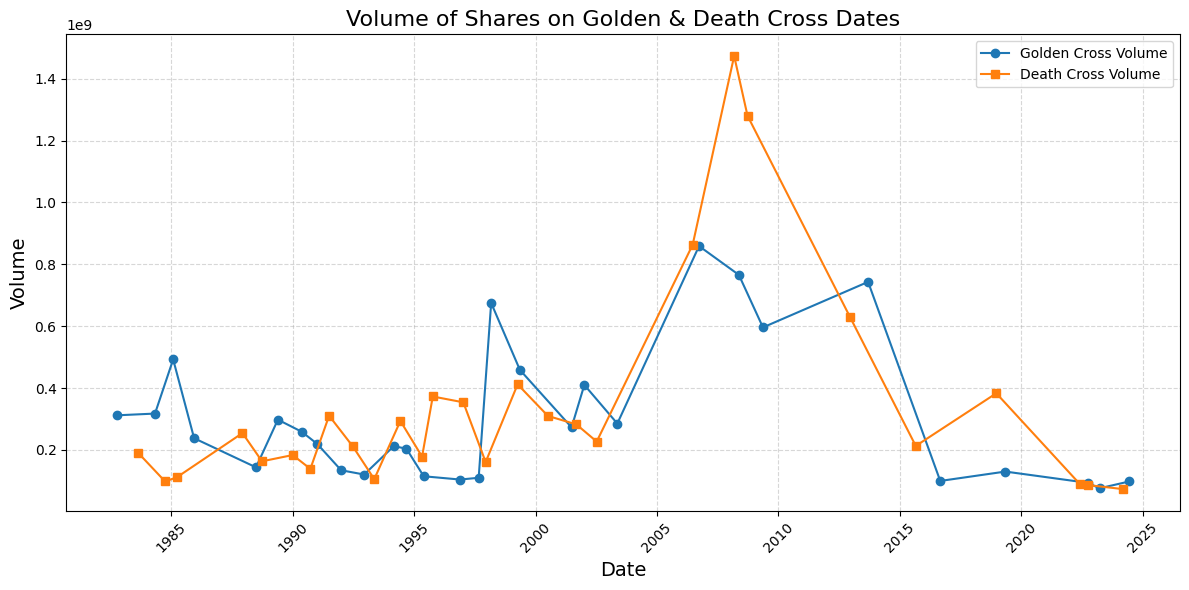

In [ ]:
# Filter date range
start_date = '2020-01-01'
end_date = '2025-12-31'

golden_filtered = golden_cross_df[
    (golden_cross_df['date'] >= start_date) & (golden_cross_df['date'] <= end_date)
]

death_filtered = death_cross_df[
    (death_cross_df['date'] >= start_date) & (death_cross_df['date'] <= end_date)
]

plt.figure(figsize=(12,6))

# Golden Cross line
plt.plot(
    golden_cross_df['date'],
    golden_cross_df['Volume'],
    marker='o',
    linestyle='-',
    label='Golden Cross Volume'
)

# Death Cross line
plt.plot(
    death_cross_df['date'],
    death_cross_df['Volume'],
    marker='s',
    linestyle='-',
    label='Death Cross Volume'
)

plt.title('Volume of Shares on Golden & Death Cross Dates', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Volume', fontsize=14)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


MODEL A: Volume ~ Close  (2020–2025)
Intercept: 216,517,649.43
Slope (per $ of Close): -817,053.14
R^2: 0.408  (fraction of Volume variance explained by Close)


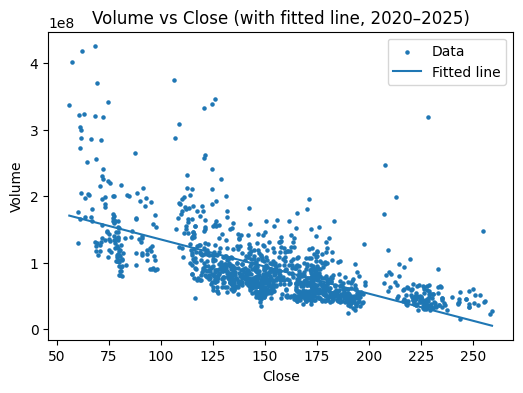

In [ ]:
# Simple linear regression: Volume ~ Close
# Slope tells how Volume changes per $1 change in Close (on average). R^2 tells
# how much of Volume's variation is explained by Close alone.

X_vol = data[["Close"]].values       # 2D array shape (n,1) for sklearn
y_vol = data["Volume"].values        # 1D target array
lin_vol = LinearRegression().fit(X_vol, y_vol)

# Predictions for R^2 and plotting the fitted line
yhat_vol = lin_vol.predict(X_vol)
r2_vol = r2_score(y_vol, yhat_vol)

print("\nMODEL A: Volume ~ Close  (2020–2025)")
print(f"Intercept: {lin_vol.intercept_:,.2f}")         # predicted Volume when Close=0 (baseline)
print(f"Slope (per $ of Close): {lin_vol.coef_[0]:,.2f}")  # how Volume changes per $1 of Close
print(f"R^2: {r2_vol:.3f}  (fraction of Volume variance explained by Close)")

# Scatter + fitted line for visual check of linear fit + direction
plt.figure(figsize=(6,4))
plt.scatter(data["Close"], data["Volume"], s=5, label="Data")
xline = np.linspace(data["Close"].min(), data["Close"].max(), 100).reshape(-1, 1)
plt.plot(xline, lin_vol.predict(xline), label="Fitted line")
plt.title("Volume vs Close (with fitted line, 2020–2025)")
plt.xlabel("Close"); plt.ylabel("Volume"); plt.legend(); plt.show()
